# 🇹🇳 Tunisian Dialogue Dataset — Deep Exploration
**Goal**: Understand the data well enough to clean it, find gaps, detect quality issues, and plan augmentation.

Sections:
1. Load & Basic Inspection
2. Missing Values & Duplicates
3. Category Distribution
4. Text Length Analysis
5. Language & Script Detection
6. Quality Signals
7. Lexical Richness & Vocabulary
8. Response Quality Flags
9. Coverage Gap Analysis
10. Summary & Recommendations

In [3]:
!pip install langdetect

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     -------------------- ----------------- 524.3/981.5 kB 1.8 MB/s eta 0:00:01
     ---------------------------------------- 981.5/981.5 kB 2.2 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-a


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# ── Optional but recommended ──────────────────────────────────────────────────
# pip install langdetect arabica
try:
    from langdetect import detect, LangDetectException
    LANGDETECT = True
except ImportError:
    LANGDETECT = False
    print("langdetect not installed — language detection section will be skipped.")
    print("Install with: pip install langdetect")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#52B788', '#9B5DE5', '#F77F00']

# ── Load ──────────────────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data\raw\categorized.csv'
df = pd.read_csv(R'C:\\Users\\user\\OneDrive\\Bureau\\TunisianDialogSystem\\llm\\sft\\data\\raw\\categorized.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (12575, 3)
Columns: ['category', 'instruction', 'response']


,category,instruction,response
0,cultural_knowledge,أعطيني لمحة على أشهر أنواع السلايط في الكوجينة...,الكوجينة التونسية معروفة بتنوع السلايط متاعها،...
1,storytelling,كيفاش يعتبر تكريم كريم بقير وزهرة سليم في مجال...,تكريم كريم بقير وزهرة سليم (مؤسسي InstaDeep) ي...
2,cultural_knowledge,كيفاش تنجم تونس تحافظ على التراث الفلكي الإسلا...,تونس تنجم تواصل في الثنية هذه عن طريق:\n• عمل ...


## Section 1 — Basic Inspection

In [5]:
print(df.dtypes)
print("\nSample entries:")
for idx, row in df.sample(3, random_state=42).iterrows():
    print(f"\n{'─'*70}")
    print(f"[category]     {row.get('category', 'N/A')}")
    print(f"[instruction]  {str(row.get('instruction', ''))[:200]}")
    print(f"[response]     {str(row.get('response', ''))[:300]}")

category       object
instruction    object
response       object
dtype: object

Sample entries:

──────────────────────────────────────────────────────────────────────
[category]     storytelling
[instruction]  احكيلي خرافة 'الذبابة والنملة' بالديرجة.
[response]     ذبابة شافت نملة تلم في القمح، قالتلها 'يا مسكينة نهار كامل وانتي تعرقي، شوفي انا ناكل مع السلاطين'. النملة قالتلها 'انا ناكل من تعبي وداري دافية في الشتاء، وانتي نهار اللي تبرد الدنيا يقتلك الشياح'. وفعلا، جاء البرد والذبابة ماتت والنملة شبعت. العبرة: 'تعب يديك ولا مزية غيرك'.

──────────────────────────────────────────────────────────────────────
[category]     general_knowledge
[instruction]  واحد كان يغزر لتصويرة (صورة) معلقة، سألوه: 'شكون هذا اللي في التصويرة؟'. جاوبهم: 'أنا ما عندي لا إخوة ولا أخوات، أما بو الراجل اللي في التصويرة هو ولد بابا'. تطلعشي عرفت شكون اللي موجود في التصويرة؟
[response]     ولده (ابن الشخص المتكلم).

──────────────────────────────────────────────────────────────────────
[category]     general

## Section 2 — Missing Values & Duplicates

In [6]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'count': missing, 'pct': missing_pct}))

print("\n=== Duplicates ===")
print(f"Exact duplicate rows:           {df.duplicated().sum()}")
print(f"Duplicate instructions:         {df['instruction'].duplicated().sum()}")
print(f"Duplicate (instr+response) pairs: {df.duplicated(subset=['instruction','response']).sum()}")

# Near-duplicates: same instruction, different response
instr_counts = df['instruction'].value_counts()
multi_response_instrs = instr_counts[instr_counts > 1]
print(f"\nInstructions with multiple responses: {len(multi_response_instrs)}")
if len(multi_response_instrs) > 0:
    print("Top 5 repeated instructions:")
    for instr, cnt in multi_response_instrs.head(5).items():
        print(f"  [{cnt}x] {str(instr)[:80]}")

=== Missing Values ===
             count  pct
category         0  0.0
instruction      0  0.0
response         0  0.0

=== Duplicates ===
Exact duplicate rows:           704
Duplicate instructions:         952
Duplicate (instr+response) pairs: 706

Instructions with multiple responses: 721
Top 5 repeated instructions:
  [10x] شنيّة المَثَل إلّي يتقال كِي واحد يحب يستحفظ بصداقة عبد وهو ديما يغدر فيه ويجبد 
  [9x] شنيّة المَثَل إلّي يتقال كِي واحد يجي يطلب حاجة من إنسان هو بيده محتاج وموش لاقي
  [7x] شنوّة يتقال لواحد ديما يلوم في غيره على فقره ولا قلة حيلته، وهو بيده موش قاعد يس
  [7x] شنوّة يتقال لواحد دخل في تجارة ولا شرا حاجة من غير ما يشاور أهل الخبرة، يا خي طل
  [6x] شنوّة يتقال لواحد ديما يتبع في الناس اللي عندهم "البخت" والحظ وما يهموش في أخلاق


## Section 3 — Category Distribution

Total unique categories: 9

Full category distribution:
category
cultural_knowledge          3509
advice_guidance             3213
general_knowledge           1316
task_oriented               1039
emotional_support            855
everyday_conversation        795
storytelling                 703
student_life                 613
opinions_recommendations     533


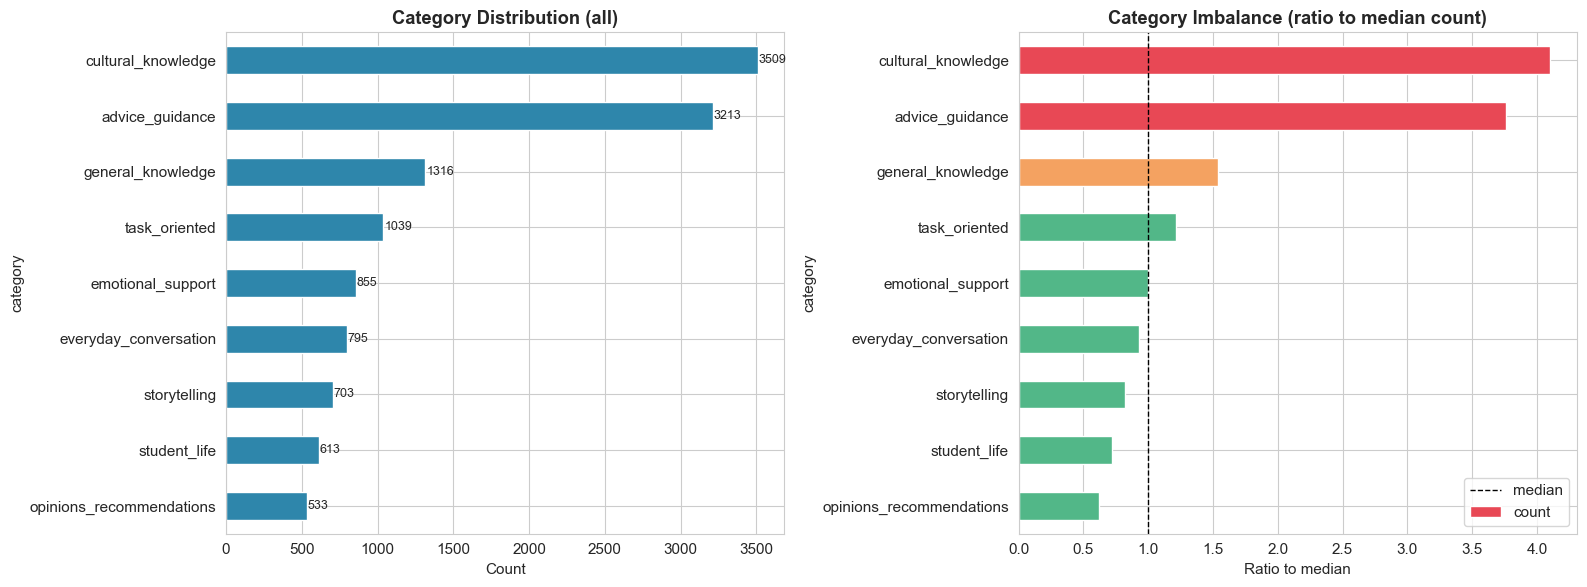


Median examples per category: 855
Most over-represented: cultural_knowledge (3509 examples)
Most under-represented: opinions_recommendations (533 examples)

⚠️ Categories with < 50 examples (need augmentation):
Series([], )


In [2]:
cat_counts = df['category'].value_counts()
print(f"Total unique categories: {len(cat_counts)}")
print("\nFull category distribution:")
print(cat_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — all categories
cat_counts.plot(kind='barh', ax=axes[0], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_title('Category Distribution (all)', fontweight='bold')
axes[0].set_xlabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va='center', fontsize=9)

# Imbalance visualization — ratio to median
median_count = cat_counts.median()
ratios = cat_counts / median_count
colors = [PALETTE[1] if r > 3 else (PALETTE[2] if r > 1.5 else PALETTE[3]) for r in ratios]
ratios.plot(kind='barh', ax=axes[1], color=colors)
axes[1].invert_yaxis()
axes[1].axvline(1, color='black', linestyle='--', linewidth=1, label='median')
axes[1].set_title('Category Imbalance (ratio to median count)', fontweight='bold')
axes[1].set_xlabel('Ratio to median')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMedian examples per category: {int(median_count)}")
print(f"Most over-represented: {cat_counts.idxmax()} ({cat_counts.max()} examples)")
print(f"Most under-represented: {cat_counts.idxmin()} ({cat_counts.min()} examples)")
print(f"\n⚠️ Categories with < 50 examples (need augmentation):")
print(cat_counts[cat_counts < 50].to_string())

## Section 4 — Text Length Analysis


INSTRUCTION
  chars — mean: 56, median: 51, min: 9, max: 479
  words — mean: 10, median: 9, min: 2, max: 91

RESPONSE
  chars — mean: 187, median: 149, min: 1, max: 1067
  words — mean: 32, median: 26, min: 1, max: 166


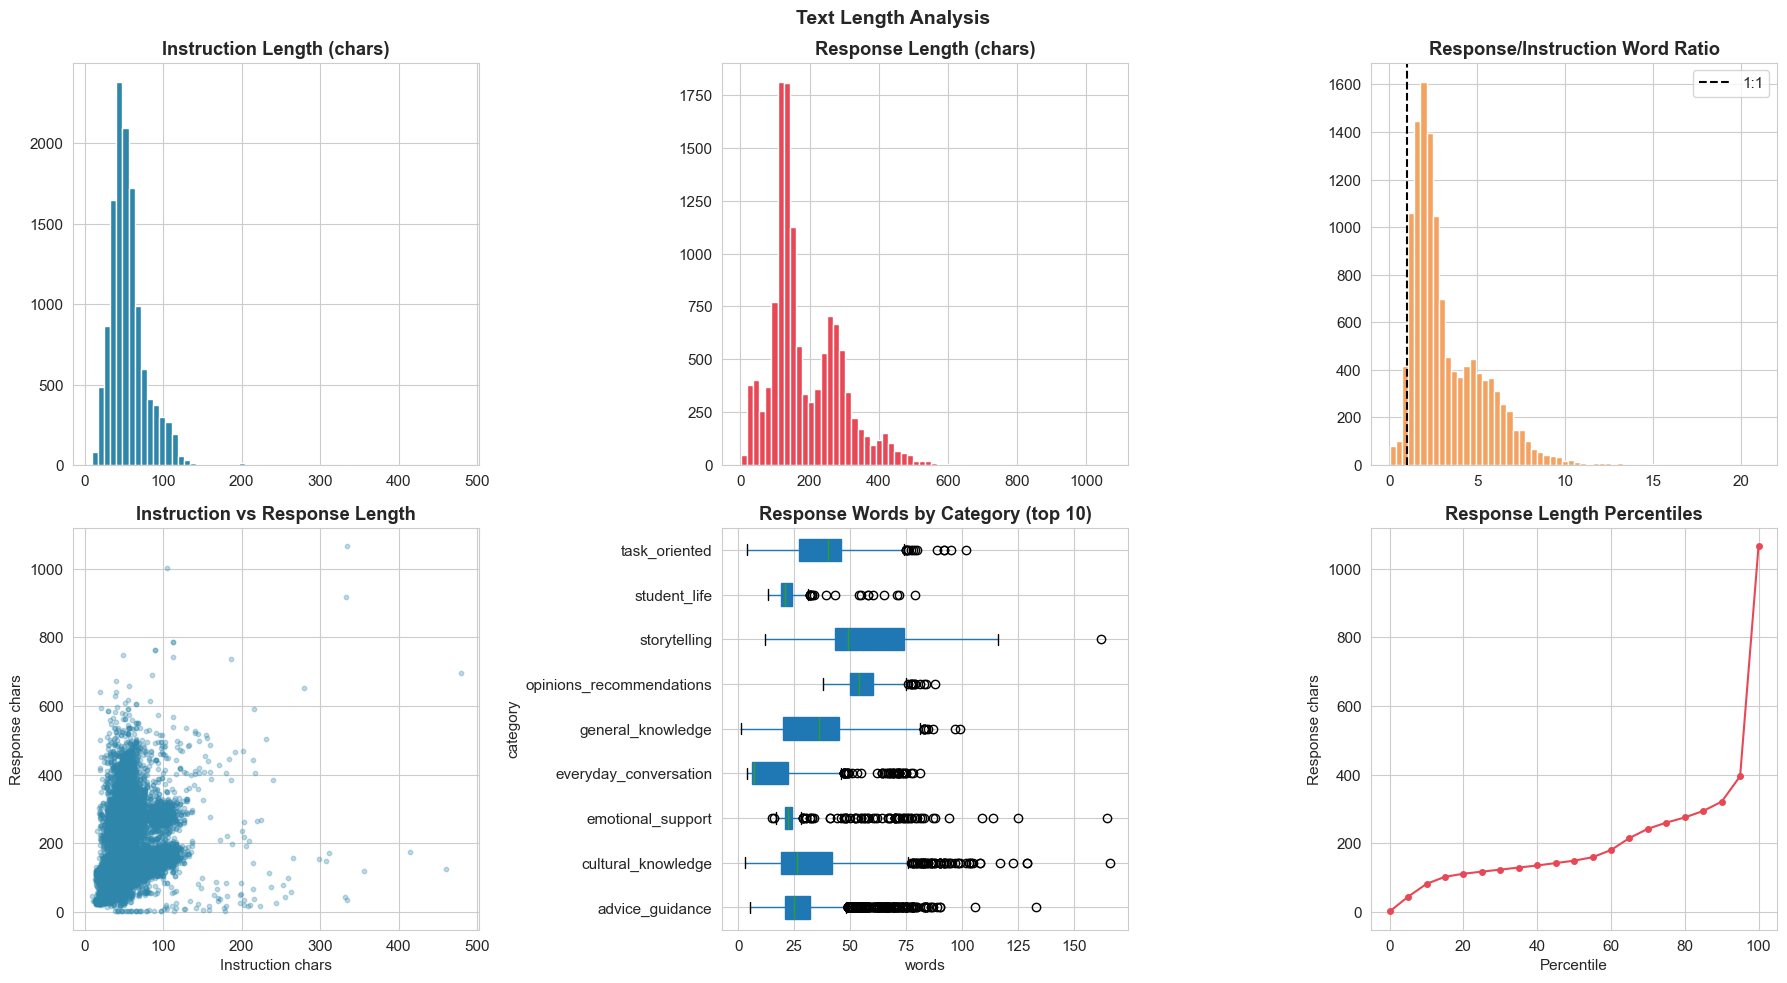


⚠️ Very short responses (< 5 words):  75 rows
⚠️ Very long responses (top 1%):      115 rows
⚠️ Very short instructions (< 3 words): 34 rows


In [3]:
df['instr_chars'] = df['instruction'].fillna('').apply(len)
df['instr_words'] = df['instruction'].fillna('').apply(lambda x: len(x.split()))
df['resp_chars']  = df['response'].fillna('').apply(len)
df['resp_words']  = df['response'].fillna('').apply(lambda x: len(x.split()))
df['resp_instr_ratio'] = df['resp_words'] / (df['instr_words'] + 1)  # +1 to avoid division by zero

for col_label, char_col, word_col in [
    ('INSTRUCTION', 'instr_chars', 'instr_words'),
    ('RESPONSE',    'resp_chars',  'resp_words')
]:
    print(f"\n{col_label}")
    print(f"  chars — mean: {df[char_col].mean():.0f}, median: {df[char_col].median():.0f}, "
          f"min: {df[char_col].min()}, max: {df[char_col].max()}")
    print(f"  words — mean: {df[word_col].mean():.0f}, median: {df[word_col].median():.0f}, "
          f"min: {df[word_col].min()}, max: {df[word_col].max()}")

# ── Plots ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].hist(df['instr_chars'], bins=60, color=PALETTE[0], edgecolor='white')
axes[0,0].set_title('Instruction Length (chars)', fontweight='bold')

axes[0,1].hist(df['resp_chars'], bins=60, color=PALETTE[1], edgecolor='white')
axes[0,1].set_title('Response Length (chars)', fontweight='bold')

axes[0,2].hist(df['resp_instr_ratio'], bins=60, color=PALETTE[2], edgecolor='white')
axes[0,2].set_title('Response/Instruction Word Ratio', fontweight='bold')
axes[0,2].axvline(1, color='black', linestyle='--', label='1:1')
axes[0,2].legend()

# Scatter: instruction vs response length
axes[1,0].scatter(df['instr_chars'], df['resp_chars'], alpha=0.3, s=10, color=PALETTE[0])
axes[1,0].set_xlabel('Instruction chars'); axes[1,0].set_ylabel('Response chars')
axes[1,0].set_title('Instruction vs Response Length', fontweight='bold')

# Box plot of response length per category (top 10)
top10_cats = df['category'].value_counts().head(10).index
df_top10 = df[df['category'].isin(top10_cats)]
df_top10.boxplot(column='resp_words', by='category', ax=axes[1,1],
                 vert=False, patch_artist=True)
axes[1,1].set_title('Response Words by Category (top 10)', fontweight='bold')
axes[1,1].set_xlabel('words')
plt.sca(axes[1,1]); plt.xticks(rotation=0)

# Percentile plot — detect outliers
percentiles = np.arange(0, 101, 5)
axes[1,2].plot(percentiles, np.percentile(df['resp_chars'], percentiles),
               color=PALETTE[1], marker='o', markersize=4)
axes[1,2].set_xlabel('Percentile'); axes[1,2].set_ylabel('Response chars')
axes[1,2].set_title('Response Length Percentiles', fontweight='bold')

plt.suptitle('Text Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag extremes
very_short_resp = df[df['resp_words'] < 5]
very_long_resp  = df[df['resp_words'] > df['resp_words'].quantile(0.99)]
very_short_instr = df[df['instr_words'] < 3]

print(f"\n⚠️ Very short responses (< 5 words):  {len(very_short_resp)} rows")
print(f"⚠️ Very long responses (top 1%):      {len(very_long_resp)} rows")
print(f"⚠️ Very short instructions (< 3 words): {len(very_short_instr)} rows")

## Section 5 — Language & Script Detection
> **Why this matters**: Tunisian is written in Arabic script, Latin script (transliterated), or mixed. You need to know the ratio before training.

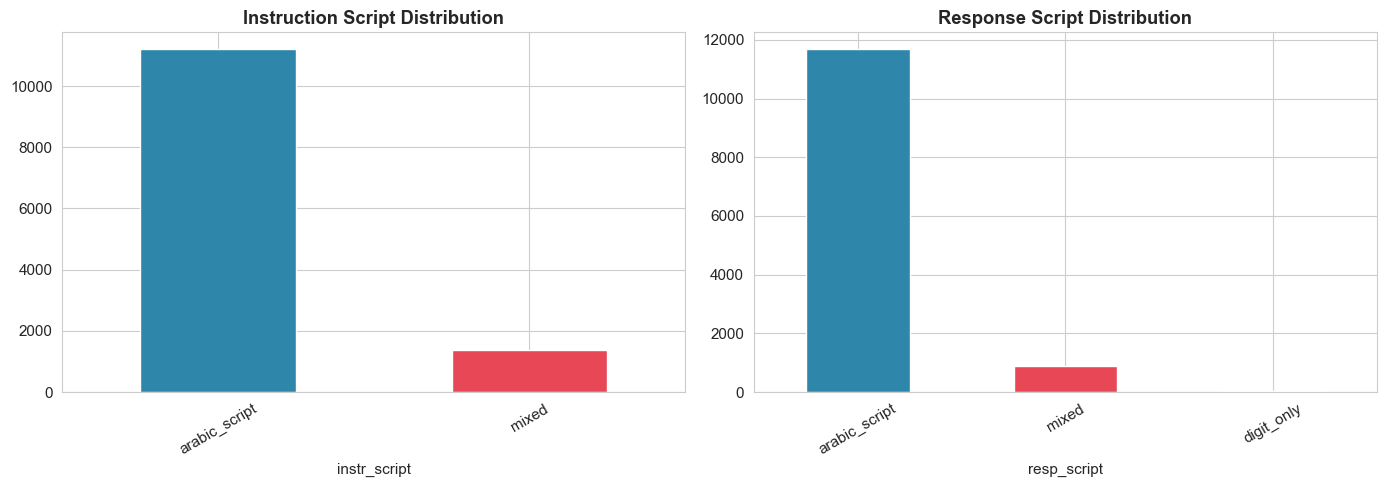

Instruction script counts:
instr_script
arabic_script    11198
mixed             1377
Name: count, dtype: int64

Response script counts:
resp_script
arabic_script    11676
mixed              873
digit_only          26
Name: count, dtype: int64

⚠️ Script mismatch (instr vs response different script): 1567 rows

Sample mismatches:
  instr (mixed): شنوة هو مشروع 'Genome Tunisia' وكيفاش باش يعاون المرضى؟
  resp  (arabic_script):  المشروع هذا يهدف لدراسة الخريطة الجينية للتوانسة. بالفهم هذا، نجموا نعرفوا الأمر

  instr (mixed): شنوة فايدة مشروع BIODESERT على الفلاحة في تونس؟
  resp  (arabic_script):  المشروع هذا يلوج على بكتيريا تعيش في الصحراء تنجم تعاون النباتات باش تقاوم العطش

  instr (arabic_script): أعطيني 10 مطاعم مشهورة في تونس العاصمة؟
  resp  (mixed):  من أشهر المطاعم في العاصمة:
1. دار الجلد (في المدينة العربي)
2. لي بو ام (Le Bo 



In [23]:
def script_profile(text):
    """Return ratio of Arabic and Latin characters, IGNORING digits and punctuation.
    
    Only meaningful text (Arabic + Latin) is used for classification percentages.
    Digits and other characters are shown for reference but don't affect the calculation.
    """
    if not isinstance(text, str) or len(text) == 0:
        return {'arabic': 0, 'latin': 0, 'digit': 0, 'other': 0}
    
    arabic = sum(1 for c in text if '\u0600' <= c <= '\u06FF')
    latin  = sum(1 for c in text if c.isalpha() and ord(c) < 128)
    digit  = sum(1 for c in text if c.isdigit())
    other  = len(text) - arabic - latin - digit
    
    # Only count meaningful text (Arabic + Latin) for classification
    meaningful_total = arabic + latin
    
    if meaningful_total == 0:
        # No Arabic or Latin text found
        return {
            'arabic': 0,
            'latin': 0,
            'digit': digit / len(text) if len(text) > 0 else 0,
            'other': other / len(text) if len(text) > 0 else 0
        }
    
    return {
        'arabic': arabic / meaningful_total,  # percentage among Arabic+Latin only
        'latin':  latin / meaningful_total,   # percentage among Arabic+Latin only
        'digit': digit / len(text) if len(text) > 0 else 0,
        'other': other / len(text) if len(text) > 0 else 0
    }

def classify_script(text):
    p = script_profile(text)
    # Check for mixed FIRST before checking for dominant scripts
    if p['arabic'] > 0.1 and p['latin'] > 0.1:
        return 'mixed'
    elif p['arabic'] > 0.4:
        return 'arabic_script'
    elif p['latin'] > 0.4:
        return 'latin_script'
    elif p['digit'] == 1.0:
        return 'digit_only'
    else:
        return 'other/unclear'

df['instr_script'] = df['instruction'].apply(classify_script)
df['resp_script']  = df['response'].apply(classify_script)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['instr_script'].value_counts().plot(kind='bar', ax=axes[0], color=PALETTE)
axes[0].set_title('Instruction Script Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

df['resp_script'].value_counts().plot(kind='bar', ax=axes[1], color=PALETTE)
axes[1].set_title('Response Script Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Instruction script counts:")
print(df['instr_script'].value_counts())
print("\nResponse script counts:")
print(df['resp_script'].value_counts())

# Mismatch: instruction in latin but response in arabic (or vice versa)
script_mismatch = df[df['instr_script'] != df['resp_script']]
print(f"\n⚠️ Script mismatch (instr vs response different script): {len(script_mismatch)} rows")
if len(script_mismatch) > 0:
    print("\nSample mismatches:")
    for _, row in script_mismatch.head(3).iterrows():
        print(f"  instr ({row['instr_script']}): {str(row['instruction'])[:80]}")
        print(f"  resp  ({row['resp_script']}):  {str(row['response'])[:80]}")
        print()

In [33]:
# ── Extract ALL Latin sequences from instructions ──────────────────────────
# Keep only MAXIMAL sequences (not contained in longer ones)
# Includes French accented characters (é, è, ê, à, ç, ù, etc.)
def extract_all_latin_sequences(text):
    """Extract ALL continuous sequences of Latin words from text.
    Includes single words, short phrases, and multi-word phrases.
    Captures French accented characters (é, è, ê, à, ç, ù, û, ü, ö, etc.)
    Returns list of sequences (each sequence = group of consecutive Latin words)."""
    if not isinstance(text, str):
        return []
    
    # Regex that captures: a-zA-Z plus French/European accented characters
    # Accented chars: àâäéèêëïîôöùûüœæçñ and uppercase versions
    latin_sequences = re.findall(
        r"[a-zA-Zàâäéèêëïîôöùûüœæçñ]+(?:\s+[a-zA-Zàâäéèêëïîôöùûüœæçñ]+)*",
        text
    )
    return [seq.lower() for seq in latin_sequences if seq.strip()]

# Extract all Latin sequences from instructions
all_latin_sequences = []
for text in df['instruction']:
    sequences = extract_all_latin_sequences(text)
    all_latin_sequences.extend(sequences)

# Count occurrences
sequence_counter = Counter(all_latin_sequences)

# Filter: keep only MAXIMAL sequences (not substrings of other sequences)
# This removes "script", "de", "soins" if "script de soins" exists
maximal_sequences = {}
for seq, count in sequence_counter.items():
    # Check if this sequence is a substring of any other sequence
    is_substring = False
    for other_seq in sequence_counter.keys():
        if seq != other_seq and seq in other_seq:
            is_substring = True
            break
    
    if not is_substring:
        maximal_sequences[seq] = count

# Sort by frequency
maximal_sequences = dict(sorted(maximal_sequences.items(), key=lambda x: x[1], reverse=True))

print(f"Total Latin sequence occurrences in instructions: {len(all_latin_sequences)}")
print(f"Unique Latin sequences: {len(sequence_counter)}")
print(f"MAXIMAL sequences (not substrings of others): {len(maximal_sequences)}\n")

print("="*80)
print("ALL MAXIMAL LATIN SEQUENCES IN INSTRUCTIONS (by frequency):")
print("(Includes French accented characters: é, è, ê, à, ç, ù, û, ü, etc.)")
print("="*80)
for sequence, count in list(maximal_sequences.items())[:2500]:
    print(f"  {count:>5}x  {sequence}")


Total Latin sequence occurrences in instructions: 2050
Unique Latin sequences: 1379
MAXIMAL sequences (not substrings of others): 1150

ALL MAXIMAL LATIN SEQUENCES IN INSTRUCTIONS (by frequency):
(Includes French accented characters: é, è, ê, à, ç, ù, û, ü, etc.)
      8x  python
      8x  hiv
      7x  biodesert
      7x  constipation
      7x  acouphènes
      7x  freelance
      6x  palpitations
      6x  talon
      6x  hba
      5x  dna
      5x  nez bouché
      5x  instruction
      5x  steg
      5x  patente
      5x  camping
      5x  carnet de soins
      5x  sida
      5x  climatiseur
      4x  gps
      4x  antibiotique
      4x  bleus
      4x  essoufflement
      4x  verrues
      4x  salle de sport
      4x  sifflement
      4x  mouches volantes
      4x  migraine
      4x  insomnie
      4x  nurésie
      4x  sécrétions
      4x  lumbago
      4x  souris
      4x  encadrant
      4x  rattrapage
      4x  lh
      4x  tsh
      4x  smartwatch
      3x  genome tunisia
   

In [34]:
# ── Extract ALL Latin sequences from responses ──────────────────────────
# Keep only MAXIMAL sequences (not contained in longer ones)
# Includes French accented characters (é, è, ê, à, ç, ù, etc.)
def extract_all_latin_sequences(text):
    """Extract ALL continuous sequences of Latin words from text.
    Includes single words, short phrases, and multi-word phrases.
    Captures French accented characters (é, è, ê, à, ç, ù, û, ü, ö, etc.)
    Returns list of sequences (each sequence = group of consecutive Latin words)."""
    if not isinstance(text, str):
        return []
    
    # Regex that captures: a-zA-Z plus French/European accented characters
    # Accented chars: àâäéèêëïîôöùûüœæçñ and uppercase versions
    latin_sequences = re.findall(
        r"[a-zA-Zàâäéèêëïîôöùûüœæçñ]+(?:\s+[a-zA-Zàâäéèêëïîôöùûüœæçñ]+)*",
        text
    )
    return [seq.lower() for seq in latin_sequences if seq.strip()]

# Extract all Latin sequences from responses
all_latin_sequences_resp = []
for text in df['response']:
    sequences = extract_all_latin_sequences(text)
    all_latin_sequences_resp.extend(sequences)

# Count occurrences
sequence_counter_resp = Counter(all_latin_sequences_resp)

# Filter: keep only MAXIMAL sequences (not substrings of other sequences)
# This removes "script", "de", "soins" if "script de soins" exists
maximal_sequences_resp = {}
for seq, count in sequence_counter_resp.items():
    # Check if this sequence is a substring of any other sequence
    is_substring = False
    for other_seq in sequence_counter_resp.keys():
        if seq != other_seq and seq in other_seq:
            is_substring = True
            break
    
    if not is_substring:
        maximal_sequences_resp[seq] = count

# Sort by frequency
maximal_sequences_resp = dict(sorted(maximal_sequences_resp.items(), key=lambda x: x[1], reverse=True))

print(f"Total Latin sequence occurrences in responses: {len(all_latin_sequences_resp)}")
print(f"Unique Latin sequences: {len(sequence_counter_resp)}")
print(f"MAXIMAL sequences (not substrings of others): {len(maximal_sequences_resp)}\n")

print("="*80)
print("ALL MAXIMAL LATIN SEQUENCES IN RESPONSES (by frequency):")
print("(Includes French accented characters: é, è, ê, à, ç, ù, û, ü, etc.)")
print("="*80)
for sequence, count in list(maximal_sequences_resp.items())[:2500]:
    print(f"  {count:>5}x  {sequence}")

Total Latin sequence occurrences in responses: 5458
Unique Latin sequences: 3071
MAXIMAL sequences (not substrings of others): 2437

ALL MAXIMAL LATIN SEQUENCES IN RESPONSES (by frequency):
(Includes French accented characters: é, è, ê, à, ç, ù, û, ü, etc.)
     21x  anémie
     17x  ecg
     16x  tsh
     14x  kinésithérapie
     14x  instruction
     13x  reflux
     13x  admis
     11x  ecbu
     11x  pylori
     11x  fibroscopie
     11x  cnss
     10x  startups
     10x  gov
     10x  gps
     10x  détartrage
     10x  beta hcg
      9x  star wars
      9x  css
      9x  biodesert
      8x  sciatique
      8x  hernie discale
      8x  networking
      8x  garantie
      7x  infection urinaire
      7x  larmes artificielles
      7x  arthrose
      7x  canal carpien
      7x  emg
      7x  steg
      7x  dinar
      7x  prélèvement
      7x  carte mère
      7x  pdf
      6x  emotional
      6x  colon irritable
      6x  myopie
      6x  champignons
      6x  glycémie à jeun
      

Responses with heavy French mixing (>10% French markers): 0
Average French marker ratio in responses: 0.000


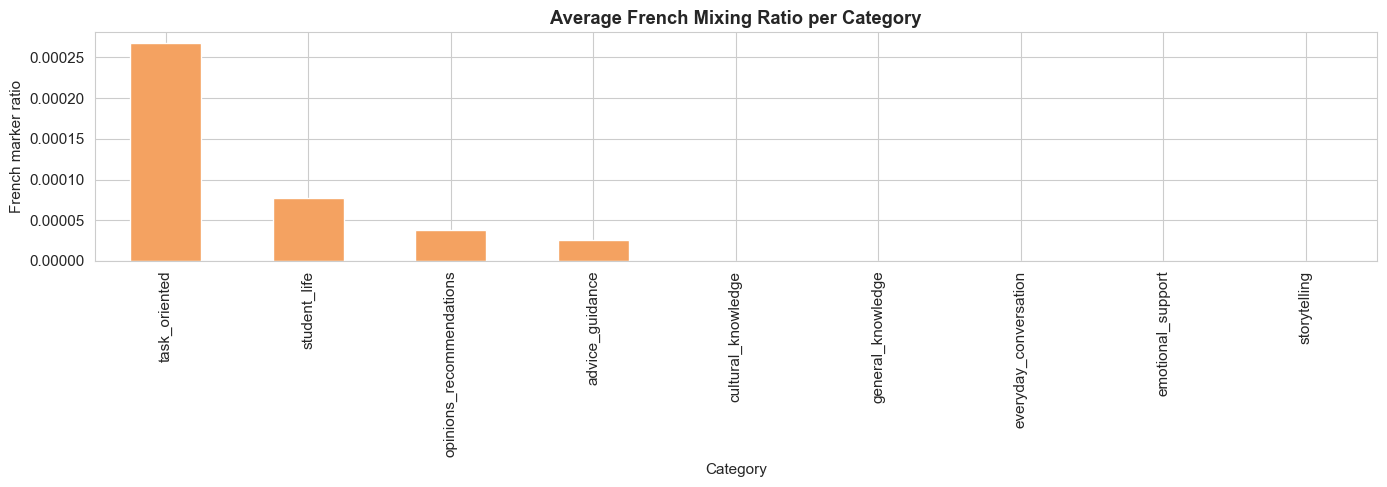

In [35]:
# ── French word detection (code-switching) ────────────────────────────────────
# Simple heuristic: common French function words
FRENCH_MARKERS = ['je', 'tu', 'il', 'elle', 'nous', 'vous', 'les', 'des', 'une', 'pour',
                  'avec', 'mais', 'donc', 'pas', 'plus', 'bien', 'aussi', 'comme', 'tout',
                  'fait', 'très', 'encore', 'déjà', 'sans', 'même', 'après']

def french_word_ratio(text):
    if not isinstance(text, str): return 0
    words = text.lower().split()
    if len(words) == 0: return 0
    return sum(1 for w in words if w in FRENCH_MARKERS) / len(words)

df['resp_french_ratio'] = df['response'].apply(french_word_ratio)
french_heavy = df[df['resp_french_ratio'] > 0.1]

print(f"Responses with heavy French mixing (>10% French markers): {len(french_heavy)}")
print(f"Average French marker ratio in responses: {df['resp_french_ratio'].mean():.3f}")

# Distribution of French mixing by category
fig, ax = plt.subplots(figsize=(14, 5))
cat_french = df.groupby('category')['resp_french_ratio'].mean().sort_values(ascending=False)
cat_french.plot(kind='bar', ax=ax, color=PALETTE[2])
ax.set_title('Average French Mixing Ratio per Category', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('French marker ratio')
plt.tight_layout()
plt.show()

## Section 6 — Quality Signals
> Detecting AI-generation artifacts, boilerplate phrases, truncated responses, and low-quality entries.

In [36]:
# ── 1. Boilerplate / AI artifact detection ────────────────────────────────────
AI_BOILERPLATE = [
    r"as an ai", r"i'm an ai", r"i am an ai",
    r"as a language model",
    r"i cannot (provide|help|assist)",
    r"i don't have (feelings|emotions|personal)",
    r"sure[,!]?\.? (here|i can|let me)",
    r"certainly[,!]?",
    r"of course[,!]?",
    r"absolutely[,!]?",
    r"great question",
    r"hope (this|that) helps",
    r"feel free to ask",
]

def count_boilerplate(text):
    if not isinstance(text, str): return 0
    text_lower = text.lower()
    return sum(1 for pat in AI_BOILERPLATE if re.search(pat, text_lower))

df['boilerplate_count'] = df['response'].apply(count_boilerplate)
boilerplate_rows = df[df['boilerplate_count'] > 0]
print(f"Responses with AI boilerplate phrases: {len(boilerplate_rows)} ({len(boilerplate_rows)/len(df)*100:.1f}%)")

# Show distribution
print(df['boilerplate_count'].value_counts().sort_index())

if len(boilerplate_rows) > 0:
    print("\nSample boilerplate-heavy responses:")
    for _, row in boilerplate_rows.nlargest(3, 'boilerplate_count').iterrows():
        print(f"  [{row['boilerplate_count']} hits] [{row['category']}] {str(row['response'])[:150]}")
        print()

Responses with AI boilerplate phrases: 0 (0.0%)
boilerplate_count
0    12575
Name: count, dtype: int64


## Section 7 — Vocabulary & Tunisian-Specific Lexicon
> Understanding what words dominate and whether they look like real Tunisian.

Response  — total tokens: 401,671, unique: 56,263
Instruction — total tokens: 125,804, unique: 23,280

Top 50 response tokens:
[('في', 14727), ('اللي', 6754), ('من', 6302), ('على', 4480), ('ما', 4202), ('باش', 3827), ('هو', 2994), ('هي', 2731), ('أما', 2056), ('،', 1618), ('لازم', 1589), ('وإلا', 1576), ('مع', 1551), ('كان', 1423), ('فيها', 1341), ('الـ', 1334), ('أو', 1288), ('هذا', 1268), ('برشة', 1184), ('تنجم', 1176), ('ولا', 1126), ('كل', 1125), ('فيه', 1119), ('وما', 1101), ('تونس', 1091), ('هذي', 1079), ('إذا', 1072), ('وقت', 995), ('خاطر', 981), ('يقولوا', 904), ('برشا', 896), ('تكون', 882), ('يكون', 838), ('حتى', 810), ('ديما', 769), ('متاع', 749), ('كيف', 724), ('بعد', 715), ('بين', 692), ('يعني', 688), ('كي', 683), ('التونسية', 679), ('الناس', 676), ('قبل', 659), ('كِي', 657), ('حاجة', 609), ('تمشي', 602), ('ينجم', 601), ('تعمل', 601), ('لازمك', 575)]


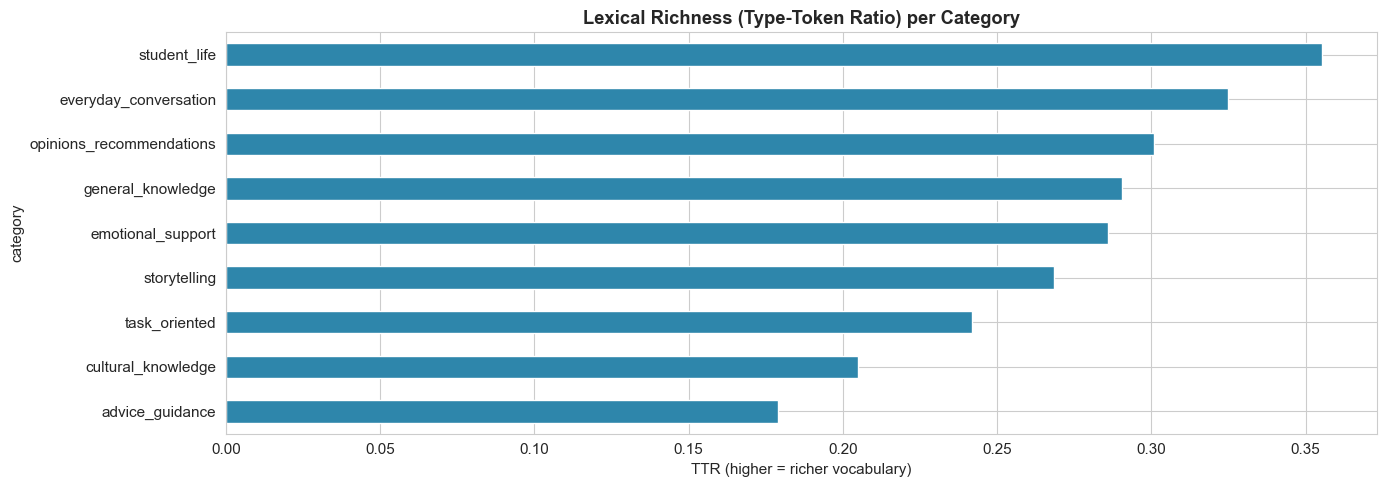

In [44]:
from collections import Counter
import re

def tokenize(text):
    if not isinstance(text, str): return []
    return re.findall(r'[\u0600-\u06FFa-zA-Z]+', text.lower())

all_resp_tokens  = [tok for text in df['response']    for tok in tokenize(text)]
all_instr_tokens = [tok for text in df['instruction'] for tok in tokenize(text)]

resp_vocab  = Counter(all_resp_tokens)
instr_vocab = Counter(all_instr_tokens)

print(f"Response  — total tokens: {len(all_resp_tokens):,}, unique: {len(resp_vocab):,}")
print(f"Instruction — total tokens: {len(all_instr_tokens):,}, unique: {len(instr_vocab):,}")

print("\nTop 50 response tokens:")
print(resp_vocab.most_common(50))

# Type-token ratio by category (proxy for lexical richness)
def ttr(texts):
    tokens = [tok for t in texts for tok in tokenize(t)]
    if len(tokens) == 0: return 0
    return len(set(tokens)) / len(tokens)

cat_ttr = df.groupby('category')['response'].apply(ttr).sort_values()

fig, ax = plt.subplots(figsize=(14, 5))
cat_ttr.plot(kind='barh', ax=ax, color=PALETTE[0])
ax.set_title('Lexical Richness (Type-Token Ratio) per Category', fontweight='bold')
ax.set_xlabel('TTR (higher = richer vocabulary)')
plt.tight_layout()
plt.show()

In [57]:
# ── Common Tunisian words check (manual small lexicon) ────────────────────────
TUN_WORDS = [
    # common Tunisian words in Arabic script
    'نحب', 'باش','بش', 'يزي', 'برشة', 'ما كان', 'كيفاش', 'علاش', 'واش', 'اش', 'فما','إيه','اي','إي'
    'مانيش', 'هوكا', 'باهي', 'موش', 'زعمة', 'أما', 'توا', 'هاك', 'فيهم','اللي','لازم', 'نجم','تنجم', 'تنجم', 'تنجمش', 'تنجموا', 'تنجمو', 'تنجموش','مشيت',
    'معناها','على خاطر','على خاطروا','ولا','باهي','وهكا'
]

def tunisian_word_count(text):
    if not isinstance(text, str): return 0
    tokens = tokenize(text)
    return sum(1 for t in tokens if t in TUN_WORDS)

df['tun_word_count'] = df['response'].apply(tunisian_word_count)

print("Responses containing at least 1 known Tunisian word:")
print(f"  {(df['tun_word_count'] > 0).sum()} / {len(df)} ({(df['tun_word_count'] > 0).mean()*100:.1f}%)")

print("\nResponses with NO detectable Tunisian markers (might be MSA or French):")
no_tun = df[df['tun_word_count'] == 0]
print(f"  {len(no_tun)} rows")

print("\nSample responses with 0 Tunisian markers:")
for _, row in no_tun.sample(min(5, len(no_tun)), random_state=1).iterrows():
    print(f"  [{row['category']}] {str(row['response'])[:150]}")
    print()

Responses containing at least 1 known Tunisian word:
  9454 / 12575 (75.2%)

Responses with NO detectable Tunisian markers (might be MSA or French):
  3121 rows

Sample responses with 0 Tunisian markers:
  [student_life] ابعد على الكافيين الزايدة ونوع في ماكلتك. الغلال والخضرة يعاونوا المخ. وأهم حاجة، ما تقارنش روحك بتقدم أصحابك، كل واحد وريتمو.

  [advice_guidance] الاستثمار في تونس فيه برشا خيارات. للأمان العالي: أذون الخزينة (Bons du Trésor) هي الأكثر أماناً لأن الدولة تضمنها. حسابات الادخار في البنوك تعطي فائد

  [cultural_knowledge] كسكسي موسمي خريفي يتعمل وقت يكثر السفرجل والزبيب في الخريف، يتميز بمذاق مميز بين الحلاوة والمرارة

  [cultural_knowledge] هو احتفال تراثي كبير فيه رقصات بالسيوف والبنادير، يجسد صراعات قديمة انتهت بالمصالحة، وهو مسجل في تراث اليونسكو.

  [general_knowledge] لازمها شهادة عزوبية من بلادها، شهادة ميلاد، وشهادة طبية للزواج، وإذا هي مش مقيمة لازمها ترخيص من القنصلية متاعها.



## Section 8 — Coverage Gap Analysis
> Which categories or question types are under-represented or missing entirely?

In [ ]:
# ── Question type analysis ────────────────────────────────────────────────────
QUESTION_PATTERNS = {
    'what/definition': r'(|شني|شنيا|شنو|اش هو)',
    'how_to':          r'(how (to|do|can)|كيفاش|kifesh|comment)',
    'why':             r'(why|علاش|pourquoi|لماذا)',
    'list/enumerate':  r'(list|give me|enumerate|اعطيني|أذكر)',
    'opinion/advice':  r'(what do you think|should i|رأيك|نصيحة|conseil)',
    'yes_no':          r'^(is|are|do|does|can|will|هل|واش|wesh)',
    'creative':        r'(write|generate|create|اكتب|أنشئ|écris)',
    'translate':       r'(translat|ترجم|traduction)',
    'math/calc':       r'(calculat|comput|احسب|\d+\s*[+\-*/]\s*\d+)',
    'code':            r'(code|program|function|script|برمج|كود)',
}

for qtype, pattern in QUESTION_PATTERNS.items():
    count = df['instruction'].fillna('').apply(
        lambda x: bool(re.search(pattern, x, re.IGNORECASE))
    ).sum()
    print(f"  {qtype:<25}: {count:>5} ({count/len(df)*100:.1f}%)")

# ── Instruction starts (first word/char) ─────────────────────────────────────
df['instr_first_word'] = df['instruction'].fillna('').apply(
    lambda x: x.strip().split()[0].lower() if x.strip() else ''
)
print("\nTop 20 instruction starting words:")
print(df['instr_first_word'].value_counts().head(20).to_string())

  what/definition          :  3790 (30.1%)
  how_to                   :  1986 (15.8%)
  why                      :   942 (7.5%)
  list/enumerate           :     8 (0.1%)
  opinion/advice           :    33 (0.3%)
  yes_no                   :    48 (0.4%)
  creative                 :     1 (0.0%)
  translate                :     5 (0.0%)
  math/calc                :    17 (0.1%)
  code                     :    54 (0.4%)

Top 20 instruction starting words:
instr_first_word
شنوة      1433
كيفاش     1304
نحب        679
احكيلي     621
علاش       586
عندي       542
نحس        529
ياخي       416
شنوّة      402
وقتاش      306
يا         280
شنيّة      277
فما        199
أشنو       194
آما        182
تنصحني     181
عطيني      135
الـ        128
وين        122
أنا        120


In [ ]:
# ── Recommended category targets for augmentation ────────────────────────────
TARGET_PER_CATEGORY = 200  # change this to your augmentation goal

cat_counts = df['category'].value_counts()
augmentation_needed = (TARGET_PER_CATEGORY - cat_counts).clip(lower=0)
augmentation_needed = augmentation_needed[augmentation_needed > 0].sort_values(ascending=False)

print(f"=== Augmentation Plan (target: {TARGET_PER_CATEGORY} per category) ===")
print(augmentation_needed.to_string())
print(f"\nTotal new samples needed: {augmentation_needed.sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
augmentation_needed.plot(kind='bar', ax=ax, color=PALETTE[4])
ax.set_title(f'Samples Needed to Reach {TARGET_PER_CATEGORY} per Category', fontweight='bold')
ax.set_ylabel('Additional samples needed')
plt.tight_layout()
plt.show()

## Section 9 — Export Clean vs Flagged Split

In [ ]:
df_clean   = df[~df['quality_issue']].copy()
df_flagged = df[df['quality_issue']].copy()

print(f"Clean rows:   {len(df_clean):,}")
print(f"Flagged rows: {len(df_flagged):,}")

# Save
OUTPUT_DIR = r'C:\Users\user\OneDrive\Bureau\TunisianDialogSystem\llm\sft\data'
df_clean.to_csv(f'{OUTPUT_DIR}\\clean.csv', index=False)
df_flagged.to_csv(f'{OUTPUT_DIR}\\flagged_for_review.csv', index=False)

print("\n✅ Saved clean.csv and flagged_for_review.csv")

## Section 10 — Summary Dashboard

In [ ]:
print("="*60)
print("DATASET HEALTH REPORT")
print("="*60)
print(f"Total rows:               {len(df):,}")
print(f"Unique categories:        {df['category'].nunique()}")
print(f"Missing instructions:     {df['instruction'].isnull().sum()}")
print(f"Missing responses:        {df['response'].isnull().sum()}")
print(f"Exact duplicates:         {df.duplicated().sum()}")
print()
print("--- Text Stats ---")
print(f"Avg instruction words:    {df['instr_words'].mean():.1f}")
print(f"Avg response words:       {df['resp_words'].mean():.1f}")
print()
print("--- Quality ---")
print(f"AI boilerplate detected:  {(df['boilerplate_count']>0).sum():,} ({(df['boilerplate_count']>0).mean()*100:.1f}%)")
print(f"Low lexical diversity:    {(df['resp_diversity']<0.4).sum():,}")
print(f"Potentially truncated:    {df['resp_truncated'].sum():,}")
print(f"Total quality-flagged:    {df['quality_issue'].sum():,} ({df['quality_issue'].mean()*100:.1f}%)")
print()
print("--- Language ---")
for script, count in df['resp_script'].value_counts().items():
    print(f"  {script:<20}: {count:,} ({count/len(df)*100:.1f}%)")
print(f"Script mismatches:        {(df['instr_script'] != df['resp_script']).sum():,}")
print("="*60)